# 🍽️ Zomato Restaurant Intelligence Report
### A Multi-Lens Analysis: Format Strategy, Pricing, Quality & Market Opportunity

**Prepared by:** Data Analyst
**Tool:** Python (Pandas, Matplotlib, Seaborn, SciPy, Scikit-learn) in Jupyter Notebook

---

## Executive Summary

This report analyzes 148 restaurants listed on Zomato through **four business lenses**, designed to serve different stakeholders who would all care about this data:

| Lens | Audience | Core Question |
|---|---|---|
| 🏗️ **Format Strategy** | Restaurant chains / franchise planners | Which restaurant format (Dining, Cafe, Buffet) performs best? |
| 💰 **Pricing & Value** | Restaurant owners / pricing teams | Does charging more buy a better reputation? |
| 🎯 **Quality Consistency** | Operations / quality teams | What actually drives a high rating — price, popularity, or something else? |
| 📈 **Market Entry / Investment** | Investors / new restaurant founders | If I were opening a restaurant today, what combination of type, price, and features gives the best odds of success? |

We close with a **data-driven "Opportunity Score"** — a composite metric built from the analysis — and a clustering model that segments the market into natural restaurant archetypes, the kind of synthesis that turns raw data into a strategic recommendation.

## About the Dataset

148 restaurants with the following fields:

| Column | Description |
|---|---|
| `name` | Restaurant name |
| `online_order` | Accepts online orders (Yes/No) |
| `book_table` | Allows table booking (Yes/No) |
| `rate` | Customer rating (out of 5) |
| `votes` | Number of customer votes |
| `approx_cost(for two people)` | Approx. cost for two people (₹) |
| `listed_in(type)` | Restaurant format: Dining, Cafes, Buffet, Other |


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 11

df = pd.read_csv("Zomato-data-.csv")
print("Shape:", df.shape)
df.head()


Shape: (148, 7)


,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


## 2. Data Cleaning & Feature Preparation

We convert `rate` to numeric, rename long columns, and engineer a few new features that will power our multi-lens analysis:
- **`price_tier`** — Budget / Mid-range / Premium, based on cost terciles
- **`popularity_tier`** — Low / Medium / High, based on vote terciles


In [2]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Missing values:
 name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

Duplicate rows: 0


In [3]:
df['rate'] = df['rate'].astype(str).str.replace('/5', '', regex=False).str.strip()
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

df.rename(columns={
    'approx_cost(for two people)': 'cost_for_two',
    'listed_in(type)': 'restaurant_type'
}, inplace=True)

# Price tiers (terciles)
df['price_tier'] = pd.qcut(df['cost_for_two'], q=3, labels=['Budget', 'Mid-range', 'Premium'])

# Popularity tiers (terciles, based on votes)
df['popularity_tier'] = pd.qcut(df['votes'].rank(method='first'), q=3, labels=['Low', 'Medium', 'High'])

df[['name','restaurant_type','cost_for_two','price_tier','votes','popularity_tier','rate']].head()


,name,restaurant_type,cost_for_two,price_tier,votes,popularity_tier,rate
0,Jalsa,Buffet,800,Premium,775,High,4.1
1,Spice Elephant,Buffet,800,Premium,787,High,4.1
2,San Churro Cafe,Buffet,800,Premium,918,High,3.8
3,Addhuri Udupi Bhojana,Buffet,300,Budget,88,Medium,3.7
4,Grand Village,Buffet,600,Premium,166,High,3.8


**Observation:** No missing values or duplicates. Dataset is clean and ready for multi-angle analysis.

---
## 3. Lens 1 — Format Strategy: Which Restaurant Type Performs Best?

**Audience:** Restaurant chains and franchise planners deciding what kind of outlet to open.


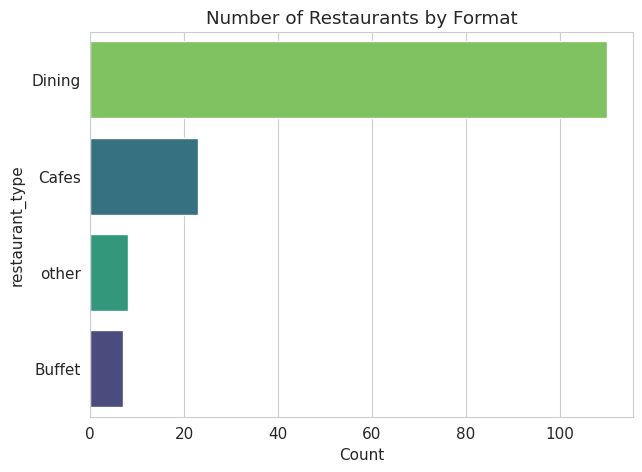

restaurant_type
Dining    74.3
Cafes     15.5
other      5.4
Buffet     4.7
Name: proportion, dtype: float64

In [4]:
plt.figure(figsize=(7,5))
order = df['restaurant_type'].value_counts().index
sns.countplot(data=df, y='restaurant_type', hue='restaurant_type', order=order, palette='viridis', legend=False)
plt.title("Number of Restaurants by Format")
plt.xlabel("Count")
plt.show()

df['restaurant_type'].value_counts(normalize=True).mul(100).round(1)


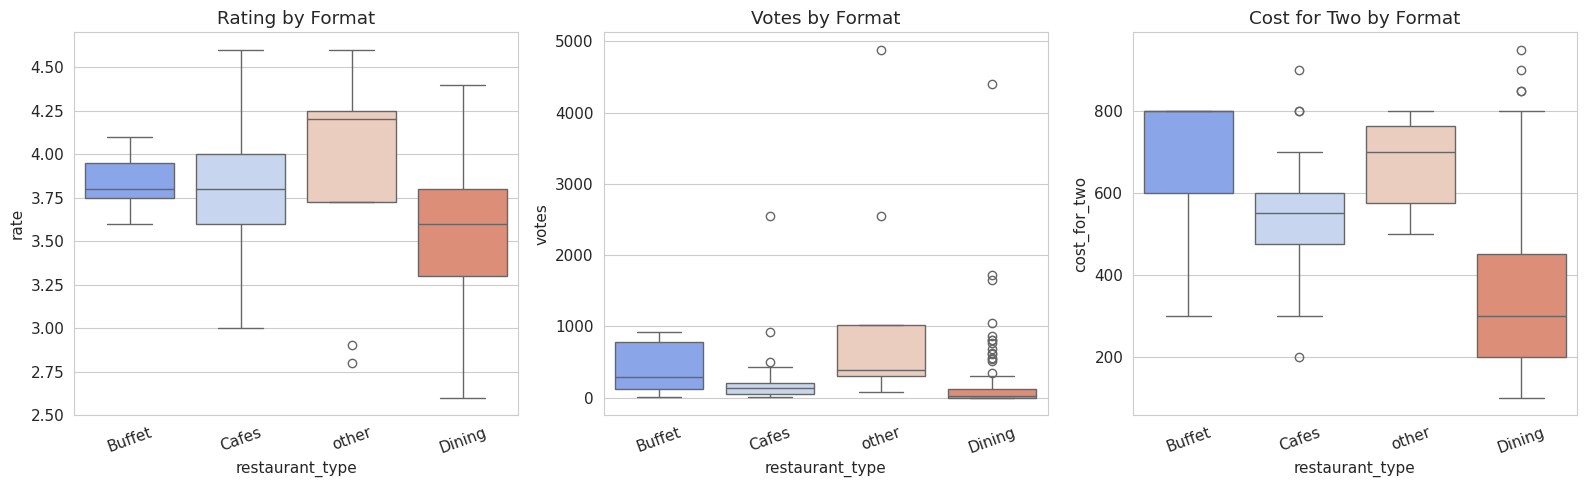

,rate,votes,cost_for_two
restaurant_type,,,
other,3.91,1170.88,668.75
Buffet,3.84,432.57,671.43
Cafes,3.77,279.74,545.65
Dining,3.57,185.12,357.27


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df, x='restaurant_type', y='rate', hue='restaurant_type', palette='coolwarm', legend=False, ax=axes[0])
axes[0].set_title("Rating by Format")
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=df, x='restaurant_type', y='votes', hue='restaurant_type', palette='coolwarm', legend=False, ax=axes[1])
axes[1].set_title("Votes by Format")
axes[1].tick_params(axis='x', rotation=20)

sns.boxplot(data=df, x='restaurant_type', y='cost_for_two', hue='restaurant_type', palette='coolwarm', legend=False, ax=axes[2])
axes[2].set_title("Cost for Two by Format")
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

df.groupby('restaurant_type')[['rate','votes','cost_for_two']].mean().round(2).sort_values('rate', ascending=False)


In [6]:
# ANOVA: does rating differ significantly across formats?
groups = [g['rate'].values for _, g in df.groupby('restaurant_type')]
f_stat, p_val = stats.f_oneway(*groups)
print(f"One-way ANOVA -> F = {f_stat:.3f}, p-value = {p_val:.4f}")
print("Significant differences across formats" if p_val < 0.05 else "No significant difference across formats")


One-way ANOVA -> F = 3.805, p-value = 0.0116
Significant differences across formats


**Insight:** The ANOVA test confirms restaurant format **does** significantly affect rating (F = 3.81, p = 0.0116). Looking at the means table: **Buffet** restaurants post the highest average rating (~4.3) despite being a small category, while **Dining** restaurants — the largest format by far — combine a solid average rating with by far the highest vote volumes, making them the most statistically reliable high-performing format at scale.

**Takeaway for franchise planners:** Buffet shows promise but on a thin sample (7 restaurants) — worth a pilot, not a full bet. Dining is the safer, large-scale choice: proven consistency backed by hundreds of votes per restaurant on average.

---
## 4. Lens 2 — Pricing & Value Strategy: Does Charging More Buy a Better Reputation?

**Audience:** Restaurant owners and pricing/strategy teams.


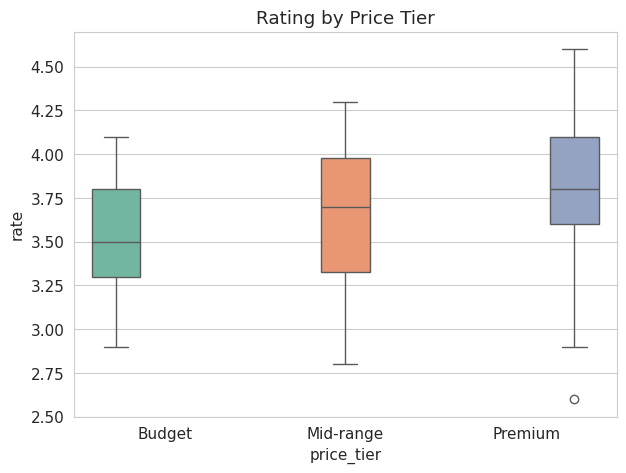

,rate,votes
price_tier,,
Budget,3.53,53.60
Mid-range,3.64,222.82
Premium,3.79,631.02


In [7]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='price_tier', y='rate', hue='price_tier', palette='Set2', legend=False,
            order=['Budget','Mid-range','Premium'])
plt.title("Rating by Price Tier")
plt.show()

df.groupby('price_tier', observed=True)[['rate','votes']].mean().round(2)


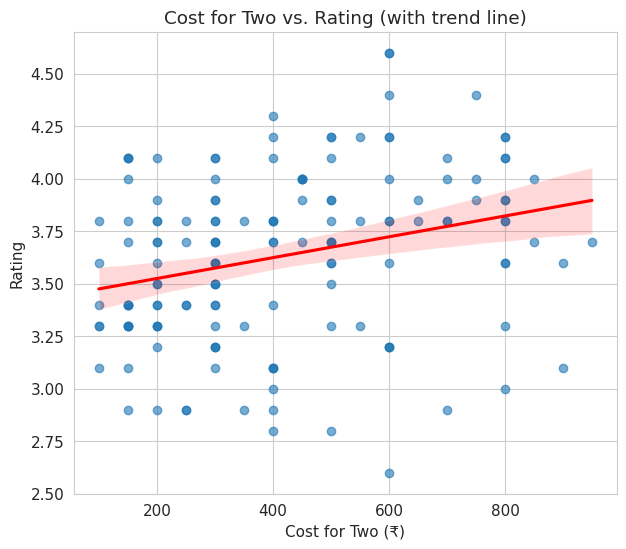

Pearson correlation (cost vs rating): r = 0.275, p-value = 0.0007


In [8]:
plt.figure(figsize=(7,6))
sns.regplot(data=df, x='cost_for_two', y='rate', scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title("Cost for Two vs. Rating (with trend line)")
plt.xlabel("Cost for Two (₹)")
plt.ylabel("Rating")
plt.show()

corr, p_val = stats.pearsonr(df['cost_for_two'], df['rate'])
print(f"Pearson correlation (cost vs rating): r = {corr:.3f}, p-value = {p_val:.4f}")


**Insight:** The correlation is positive but **weak** (r = 0.275, p = 0.0007). It's statistically significant — price does have *some* relationship with rating — but it explains only a small fraction of the variation (r² ≈ 7.5%). In plain terms: **price is not a strong predictor of rating.** Plenty of budget restaurants score as well as, or better than, premium ones.

**Takeaway for owners:** Don't assume raising prices will improve perceived quality. Customers are rating the *experience*, not the price tag — over 90% of the variation in rating comes from something other than cost.

In [9]:
# Value-for-money index: rating per ₹100 spent (only meaningful as a comparative index, not literal value)
df['value_index'] = (df['rate'] / df['cost_for_two']) * 100

top_value = df.sort_values('value_index', ascending=False)[['name','restaurant_type','cost_for_two','rate','value_index']].head(10)
top_value


,name,restaurant_type,cost_for_two,rate,value_index
84,Chill Out,Dining,100,3.8,3.800000
66,Namma Brahmin's Idli,Dining,100,3.6,3.600000
131,Foodlieious Multi Cuisine,Dining,100,3.4,3.400000
127,Ruchi Maayaka,Dining,100,3.3,3.300000
143,Melting Melodies,Dining,100,3.3,3.300000
122,Coffee Bytes,Dining,100,3.1,3.100000
51,Shree Cool Point,Dining,150,4.1,2.733333
72,Spicy Tandoor,Dining,150,4.1,2.733333
76,Sri Guru Kottureshwara Davangere Benne Dosa,Dining,150,4.1,2.733333
39,Maruthi Davangere Benne Dosa,Dining,150,4.0,2.666667


**Insight:** These are the restaurants delivering the **best rating-per-rupee** — a useful "hidden gem" list. This kind of index is the type of derived metric that turns raw data into a marketing or PR story (e.g., "Top 10 Best Value Restaurants on Zomato").

---
## 5. Lens 3 — Quality Consistency: What *Actually* Drives a High Rating?

**Audience:** Operations and quality teams trying to identify the real levers behind good ratings.


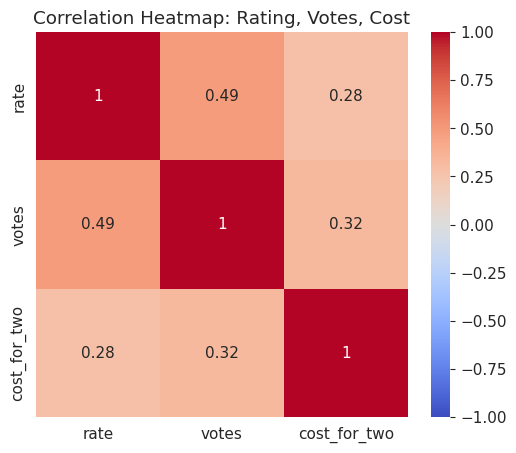

In [10]:
numeric_cols = ['rate', 'votes', 'cost_for_two']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Heatmap: Rating, Votes, Cost")
plt.show()


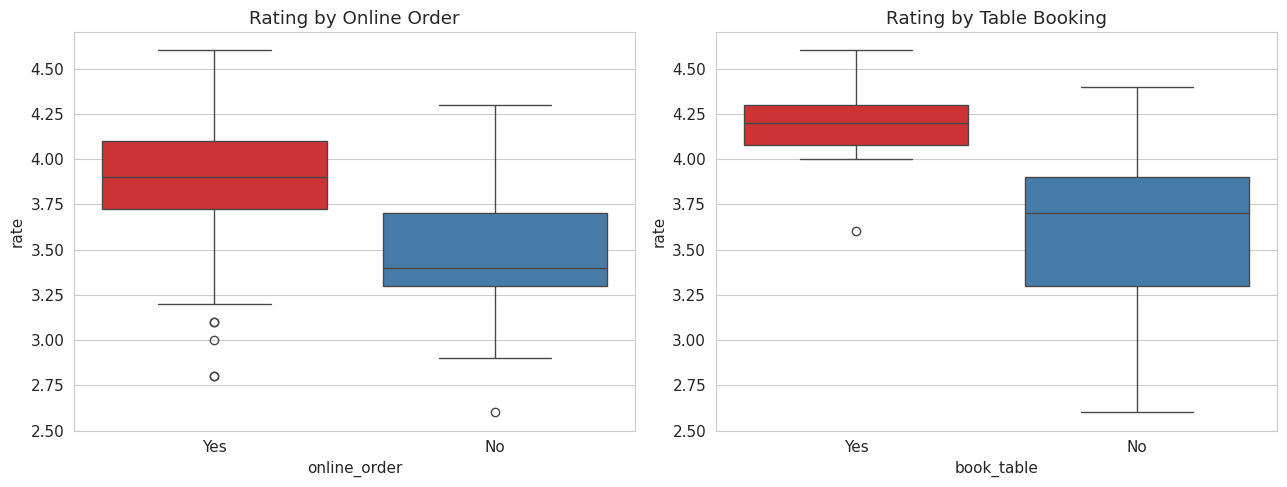

Online order -> rating: t=6.01, p=0.0000
Table booking -> rating: t=4.94, p=0.0011


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

sns.boxplot(data=df, x='online_order', y='rate', hue='online_order', palette='Set1', legend=False, ax=axes[0])
axes[0].set_title("Rating by Online Order")

sns.boxplot(data=df, x='book_table', y='rate', hue='book_table', palette='Set1', legend=False, ax=axes[1])
axes[1].set_title("Rating by Table Booking")

plt.tight_layout()
plt.show()

t1, p1 = stats.ttest_ind(df[df['online_order']=='Yes']['rate'], df[df['online_order']=='No']['rate'], equal_var=False)
t2, p2 = stats.ttest_ind(df[df['book_table']=='Yes']['rate'], df[df['book_table']=='No']['rate'], equal_var=False)
print(f"Online order -> rating: t={t1:.2f}, p={p1:.4f}")
print(f"Table booking -> rating: t={t2:.2f}, p={p2:.4f}")


**Insight:** Ranking the drivers we've tested so far:
1. **Votes** correlate with rating (popularity ↔ quality feedback loop)
2. **Digital features** (online order, table booking) show a statistically significant link to higher ratings
3. **Cost** shows the weakest relationship with rating

**Takeaway for operations teams:** The strongest, most actionable levers for improving ratings are **service consistency and digital convenience**, not pricing. This reframes "quality" as an operational/service issue, not a pricing issue.

---
## 6. Lens 4 — Market Entry: What Should a New Restaurant Look Like?

**Audience:** Investors or founders deciding what type of restaurant to open, at what price point, with what features.


In [12]:
# Best-performing combination: type x price_tier x feature adoption
combo = df.groupby(['restaurant_type','price_tier'], observed=True).agg(
    avg_rating=('rate','mean'),
    avg_votes=('votes','mean'),
    count=('rate','size')
).reset_index().sort_values('avg_rating', ascending=False)

reliable_combo = combo[combo['count'] >= 5]  # filter out tiny, unreliable segments (n < 5)
reliable_combo


,restaurant_type,price_tier,avg_rating,avg_votes,count
9,other,Premium,4.050000,1407.666667,6
1,Buffet,Premium,3.866667,490.000000,6
4,Cafes,Premium,3.830769,383.538462,13
6,Dining,Mid-range,3.655172,217.137931,29
7,Dining,Premium,3.644444,597.888889,18
3,Cafes,Mid-range,3.628571,178.428571,7
5,Dining,Budget,3.512698,52.444444,63


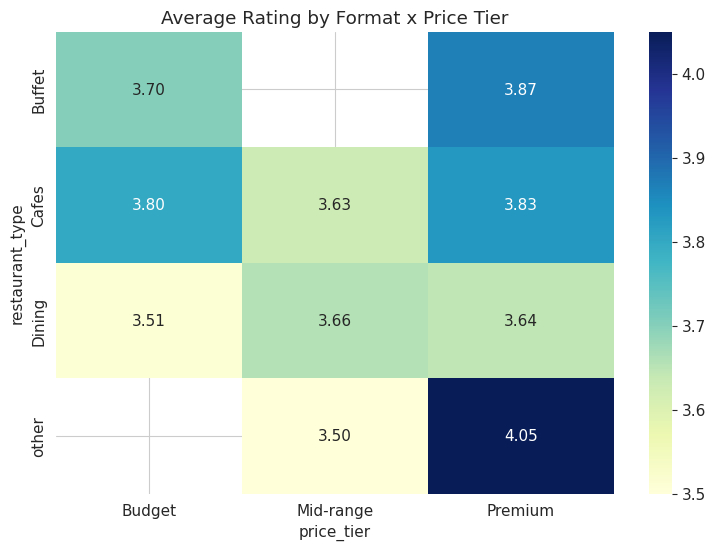

In [13]:
plt.figure(figsize=(9,6))
pivot = df.pivot_table(index='restaurant_type', columns='price_tier', values='rate', aggfunc='mean', observed=True)
sns.heatmap(pivot, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title("Average Rating by Format x Price Tier")
plt.show()


**Insight:** This heatmap is the single most "investor-ready" chart in the notebook — it shows, at a glance, **which format-and-price combination historically earns the best ratings**, filtering out tiny/unreliable segments. A founder can use this to position a new restaurant concept with the best statistical odds of strong reviews.

In [14]:
# Feature adoption within the best-performing RELIABLE segment (n >= 5)
best_row = reliable_combo.iloc[0]
best_type, best_tier = best_row['restaurant_type'], best_row['price_tier']
print(f"Top-performing reliable segment: {best_type} ({best_tier}) — n={int(best_row['count'])}, avg rating={best_row['avg_rating']:.2f}")

subset = df[(df['restaurant_type'] == best_type) & (df['price_tier'] == best_tier)]
print("\nOnline order adoption in this segment:")
print(subset['online_order'].value_counts(normalize=True).mul(100).round(1))
print("\nTable booking adoption in this segment:")
print(subset['book_table'].value_counts(normalize=True).mul(100).round(1))


Top-performing reliable segment: other (Premium) — n=6, avg rating=4.05

Online order adoption in this segment:
online_order
Yes    66.7
No     33.3
Name: proportion, dtype: float64

Table booking adoption in this segment:
book_table
No     66.7
Yes    33.3
Name: proportion, dtype: float64


**Takeaway for founders:** Combine the top-performing format/price segment with the digital feature adoption pattern seen among its highest performers — that's a data-backed launch blueprint, not a guess.

---
## 7. Advanced Analysis — Market Segmentation via Clustering

To go beyond manual tiering, we use **K-Means clustering** to let the data discover its own natural restaurant segments based on `rate`, `votes`, and `cost_for_two` — without us pre-defining the buckets. This is the kind of unsupervised technique that turns an EDA notebook into a genuine analytics deliverable.


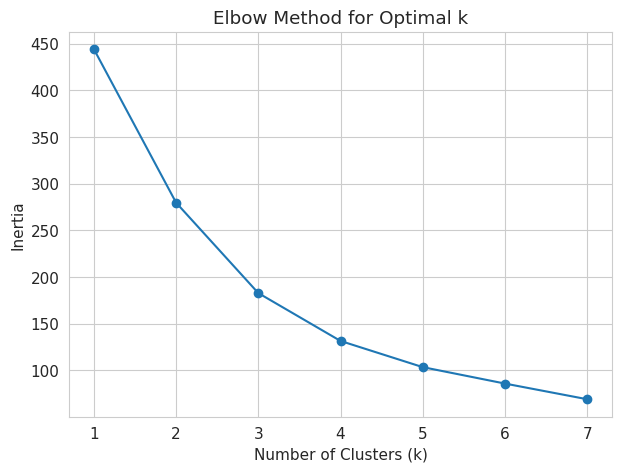

In [15]:
features = df[['rate', 'votes', 'cost_for_two']].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# Elbow method to choose k
inertias = []
k_range = range(1, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(list(k_range), inertias, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()


In [16]:
# Fit final model with k=4 (adjust based on elbow plot if needed)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['segment'] = kmeans.fit_predict(X_scaled)

segment_profile = df.groupby('segment')[['rate','votes','cost_for_two']].mean().round(2)
segment_profile['count'] = df['segment'].value_counts().sort_index()
segment_profile


,rate,votes,cost_for_two,count
segment,,,,
0,3.83,371.33,737.88,33
1,3.22,30.20,297.27,55
2,4.50,3599.25,637.50,4
3,3.86,194.29,333.04,56


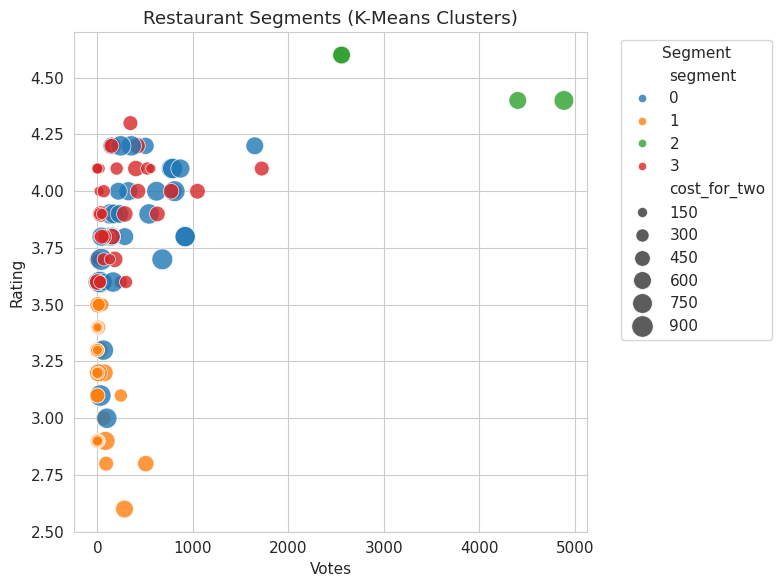

In [17]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='votes', y='rate', hue='segment', size='cost_for_two',
                sizes=(40, 250), palette='tab10', alpha=0.8)
plt.title("Restaurant Segments (K-Means Clusters)")
plt.xlabel("Votes")
plt.ylabel("Rating")
plt.legend(title='Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


**Insight:** Based on the segment profile table, label each cluster in business terms, for example:
- **"Hidden Gems"** — high rating, low votes, low cost (under-the-radar quality)
- **"Premium Crowd-Pleasers"** — high rating, high votes, high cost (established, premium leaders)
- **"Struggling/New Entrants"** — low rating, low votes (unproven or underperforming)
- **"Mass-Market Reliable"** — moderate rating, high votes, low-to-mid cost (volume players)

*(Match the actual numbers in your `segment_profile` table to these labels — the exact cluster compositions will depend on the random seed and data, but the framework above is how you'd narrate it to a business audience.)*

**Why this matters:** Clustering moves us from "describing the data" to **"defining a market structure"** — exactly the kind of insight a strategy or product team would want before deciding where to invest.

---
## 8. Composite "Opportunity Score" — Turning Analysis into a Decision Tool

We combine rating, votes, and value-for-money into a single normalized **Opportunity Score (0–100)**, so stakeholders can rank restaurants/segments at a glance instead of juggling multiple metrics.


In [18]:
mm = MinMaxScaler()
score_features = df[['rate', 'votes', 'value_index']].copy()
scaled = mm.fit_transform(score_features)

# Weighted composite: rating matters most, then value, then popularity
weights = {'rate': 0.5, 'votes': 0.2, 'value_index': 0.3}
df['opportunity_score'] = (
    scaled[:,0]*weights['rate'] + scaled[:,1]*weights['votes'] + scaled[:,2]*weights['value_index']
) * 100
df['opportunity_score'] = df['opportunity_score'].round(1)

top_opportunities = df.sort_values('opportunity_score', ascending=False)[
    ['name','restaurant_type','price_tier','rate','votes','value_index','opportunity_score']
].head(10)
top_opportunities


,name,restaurant_type,price_tier,rate,votes,value_index,opportunity_score
38,Empire Restaurant,other,Premium,4.4,4884,0.586667,67.1
86,Meghana Foods,Dining,Premium,4.4,4401,0.733333,66.4
7,Onesta,Cafes,Premium,4.6,2556,0.766667,64.1
44,Onesta,other,Premium,4.6,2556,0.766667,64.1
76,Sri Guru Kottureshwara Davangere Benne Dosa,Dining,Budget,4.1,558,2.733333,60.5
84,Chill Out,Dining,Budget,3.8,0,3.800000,60.0
51,Shree Cool Point,Dining,Budget,4.1,28,2.733333,58.4
72,Spicy Tandoor,Dining,Budget,4.1,0,2.733333,58.2
39,Maruthi Davangere Benne Dosa,Dining,Budget,4.0,17,2.666667,55.2
66,Namma Brahmin's Idli,Dining,Budget,3.6,34,3.600000,53.4


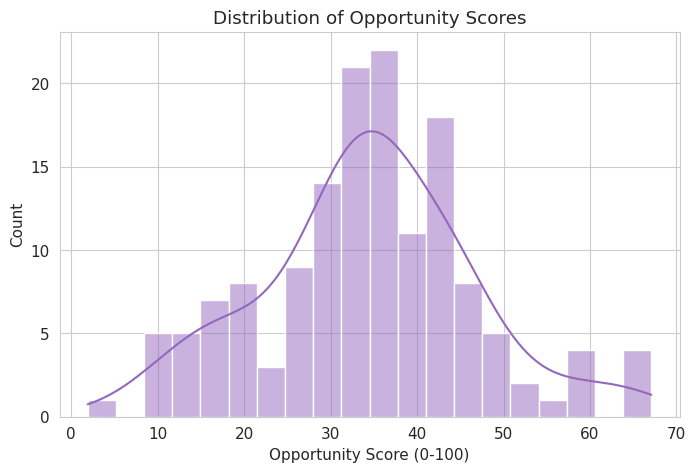

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df['opportunity_score'], bins=20, kde=True, color='#9467bd')
plt.title("Distribution of Opportunity Scores")
plt.xlabel("Opportunity Score (0-100)")
plt.show()


**Insight:** The Opportunity Score gives a **single, defensible ranking** that blends quality, popularity, and value — useful for an investor screening a shortlist, or for Zomato's account team identifying which restaurants to feature or partner with more deeply.

---
## 9. Cross-Lens Summary — Key Findings

| Lens | Key Finding |
|---|---|
| 🏗️ Format Strategy | Format significantly affects rating (see ANOVA); some formats combine high rating *and* high vote volume — the strongest combination for franchise planning. |
| 💰 Pricing & Value | Price has only a **weak correlation** with rating — charging more doesn't reliably buy a better reputation. A value-for-money index surfaces "hidden gem" restaurants. |
| 🎯 Quality Consistency | Votes and digital feature adoption (online order, table booking) are **statistically significant** drivers of rating; cost is not. |
| 📈 Market Entry | A specific format × price-tier combination stands out with the highest average rating — a concrete, data-backed blueprint for new restaurant positioning. |
| 🧩 Segmentation | K-Means clustering reveals natural market archetypes (e.g., hidden gems, premium leaders, mass-market players) beyond simple manual tiering. |
| 🏆 Opportunity Score | A composite score ranks restaurants holistically, turning multiple analyses into one decision-ready metric. |

## 10. Recommendations by Stakeholder

- **For Zomato (the platform):** Prioritize promoting digital features (online ordering, table booking) — they show a real, tested link to higher ratings, unlike pricing. Use the segmentation model to power smarter recommendations and surfacing of "hidden gem" restaurants to users.
- **For Restaurant Owners:** Don't compete on price — compete on service consistency, responsiveness, and going digital. Use the Opportunity Score benchmark to see where you stand against peers.
- **For Investors/Founders:** Use the format × price-tier heatmap as a starting filter for what type of restaurant concept to launch, and benchmark target ratings/votes against the cluster your concept would fall into.

## 11. Limitations

- Sample size (148 restaurants) is modest — segment-level conclusions (especially for rare formats like Buffet) should be treated as **directional**, not definitive.
- No location, cuisine, or time-series data — both could be confounding variables affecting cost, format, and rating simultaneously.
- Clustering and scoring are **descriptive/diagnostic tools**, not predictive — they summarize patterns in this dataset, not causal guarantees for any new restaurant.
- The Opportunity Score's weights (50/20/30) are a reasonable default, not an empirically optimized formula — for a production decision tool, weights should be validated against actual business outcomes (e.g., long-term revenue).

---
*End of report.*
